In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_excel("Dataset for Data Analytics.xlsx")

# Display first few records
print("--- FIRST 5 ROWS ---")
display(df.head())

--- FIRST 5 ROWS ---


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
print("--- DATASET SUMMARY INFO ---")
df.info()

# Check for missing values
print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())

# Handle data cleaning tasks
# 1. Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Fill missing Coupon Code records with 'NO_COUPON'
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

print("\n--- MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())

--- DATASET SUMMARY INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime

In [ ]:
# Generate basic summary statistics for numerical metrics
print("--- DESCRIPTIVE STATISTICS FOR NUMERICAL METRICS ---")
display(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe())

--- DESCRIPTIVE STATISTICS FOR NUMERICAL METRICS ---


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [ ]:
# 1. Product Analysis (Sorted by Total Revenue)
product_analysis = df.groupby('Product').agg(
    Quantity_Sold=('Quantity', 'sum'),
    Total_Revenue=('TotalPrice', 'sum'),
    Average_UnitPrice=('UnitPrice', 'mean'),
    Order_Count=('OrderID', 'count')
).sort_values(by='Total_Revenue', ascending=False)

print("--- PRODUCT PERFORMANCE ANALYSIS ---")
display(product_analysis)

# 2. Payment Method Popularity
payment_analysis = df.groupby('PaymentMethod').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

print("\n--- PAYMENT METHOD ANALYSIS ---")
display(payment_analysis)

# 3. Referral Source Success
referral_analysis = df.groupby('ReferralSource').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

print("\n--- REFERRAL SOURCE ANALYSIS ---")
display(referral_analysis)

--- PRODUCT PERFORMANCE ANALYSIS ---


,Quantity_Sold,Total_Revenue,Average_UnitPrice,Order_Count
Product,,,,
Chair,562,195620.11,355.660281,178
Printer,542,195612.61,351.714917,181
Laptop,535,192126.56,357.707052,173
Tablet,497,186568.95,367.679106,179
Monitor,480,175651.41,358.663620,163
Desk,508,167459.93,329.608118,170
Phone,411,151722.39,375.217564,156



--- PAYMENT METHOD ANALYSIS ---


,Order_Count,Total_Revenue
PaymentMethod,,
Credit Card,234,263847.63
Online,258,262442.94
Cash,246,259786.29
Gift Card,230,246323.92
Debit Card,232,232361.18



--- REFERRAL SOURCE ANALYSIS ---


,Order_Count,Total_Revenue
ReferralSource,,
Instagram,259,275285.45
Email,250,261808.55
Google,241,250441.48
Facebook,228,250410.90
Referral,222,226815.58


/tmp/ipykernel_15956/3829578090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_analysis.reset_index(), x='Product', y='Total_Revenue', palette='Blues_r')


<Figure size 1000x600 with 0 Axes>

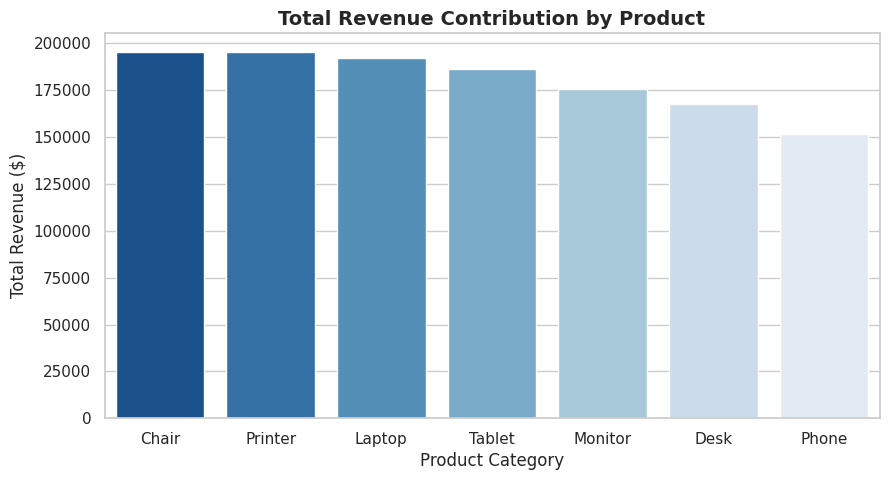

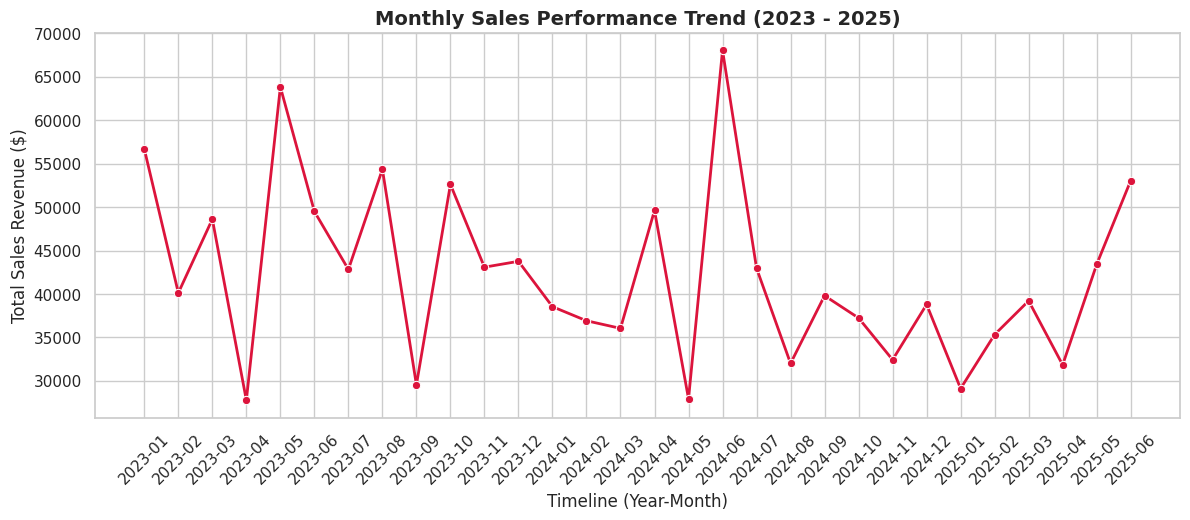

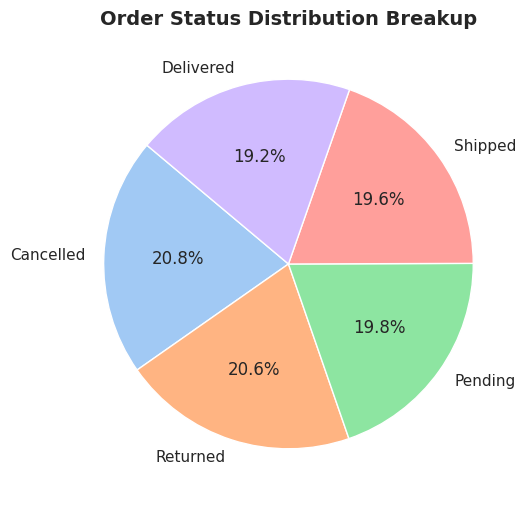

In [ ]:
# Ensure figures don't clip text
plt.tight_layout()

# 1. Product Revenue Distribution (Sorted Order)
plt.figure(figsize=(10, 5))
sns.barplot(data=product_analysis.reset_index(), x='Product', y='Total_Revenue', palette='Blues_r')
plt.title('Total Revenue Contribution by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.savefig('product_revenue.png', bbox_inches='tight')
plt.show()

# 2. Monthly Sales Trend Over Time
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalPrice', marker='o', color='crimson', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Sales Performance Trend (2023 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Year-Month)')
plt.ylabel('Total Sales Revenue ($)')
plt.savefig('monthly_sales_trend.png', bbox_inches='tight')
plt.show()

# 3. Order Status Proportions
plt.figure(figsize=(6, 6))
status_counts = df['OrderStatus'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Order Status Distribution Breakup', fontsize=14, fontweight='bold')
plt.savefig('order_status_pie.png', bbox_inches='tight')
plt.show()

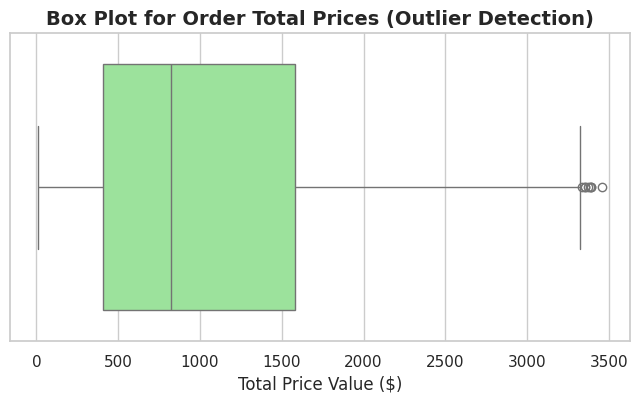

Interquartile Range Boundaries:
Lower Bound Threshold: -1341.41
Upper Bound Threshold: 3330.41
Total Number of Outlier Orders Detected: 8

--- TOP OUTLIER TRANSACTIONS ---


,OrderID,Product,Quantity,UnitPrice,TotalPrice
107,ORD200107,Printer,5,670.75,3353.75
326,ORD200326,Laptop,5,670.48,3352.40
328,ORD200328,Tablet,5,674.04,3370.20
469,ORD200469,Chair,5,676.98,3384.90
632,ORD200632,Laptop,5,678.16,3390.80
789,ORD200789,Tablet,5,691.28,3456.40
1065,ORD201065,Printer,5,666.80,3334.00
1122,ORD201122,Monitor,5,678.19,3390.95


In [ ]:
# Using the Interquartile Range (IQR) method to find revenue outliers
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]

# Visualizing Outliers using Box Plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalPrice'], color='lightgreen')
plt.title('Box Plot for Order Total Prices (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Total Price Value ($)')
plt.savefig('total_price_boxplot.png', bbox_inches='tight')
plt.show()

print(f"Interquartile Range Boundaries:")
print(f"Lower Bound Threshold: {lower_bound:.2f}")
print(f"Upper Bound Threshold: {upper_bound:.2f}")
print(f"Total Number of Outlier Orders Detected: {len(outliers)}")
print("\n--- TOP OUTLIER TRANSACTIONS ---")
display(outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].head(10))

In [15]:
df.to_excel('processed_data.xlsx', index=False)
print("Processed data saved to 'processed_data.xlsx'")

Processed data saved to 'processed_data.xlsx'
